In [169]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from copy import deepcopy
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()

In [170]:

data_dir = "C:/Users/takat/Desktop/sotuken/dat_to_images_64"


label_dict = {
    # Mild (0)
    'AF483470.1.pbm': 0, 'EF192393.1.pbm': 0, 'EF192394.1.pbm': 0,
    'EF580923.1.pbm': 0, 'EU879915.1.pbm': 0, 'EU879916.1.pbm': 0,
    'JQ806338.1.pbm': 0, 'KF418767.1.pbm': 0, 'KR611355.1.pbm': 0,
    'KT987925.1.pbm': 0, 'LC388852.1.pbm': 0, 'LC388854.1.pbm': 0,
    'M25199.1.pbm': 0, 'MG450357.1.pbm': 0, 'Y09575.1.pbm': 0,

    # Moderate (1)
    'AF454395.1.pbm': 1, 'KF683200.1.pbm': 1, 'KJ857496.1.pbm': 1,
    'KR611360.1.pbm': 1, 'M88678.1.pbm': 1, 'X17268.1.pbm': 1,
    'GQ853461.1.pbm': 1, 'EU879913.1.pbm': 1,

    # Severe (2)
    'AJ634596.1.pbm': 2, 'AY518939.1.pbm': 2, 'AY532801.1.pbm': 2,
    'DD220185.1.pbm': 2, 'FR851463.1.pbm': 2, 'JX280944.1.pbm': 2,
    'U23060.1.pbm': 2, 'X58388.1.pbm': 2, 'X76846.1.pbm': 2,
    'X97387.1.pbm': 2, 'Y09383.1.pbm': 2, 'LC523672.1.pbm': 2,
    'LC523675.1.pbm': 2, 'LC523676.1.pbm': 2
}


labeled_pbm = list(label_dict.keys())
print(labeled_pbm)
labels = list(label_dict.values())


filepaths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".pbm")]


labels_list = [label_dict.get(os.path.basename(fp), -1) for fp in filepaths]


IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 1
num_classes = 3
label_map = {0: "mild", 1: "moderate", 2: "severe"}

print(f"ラベル付きデータの数: {len(labeled_pbm)}")
print(f"全ファイル数: {len(filepaths)}")
print(f"未ラベルファイルの数: {labels_list.count(-1)}")

['AF483470.1.pbm', 'EF192393.1.pbm', 'EF192394.1.pbm', 'EF580923.1.pbm', 'EU879915.1.pbm', 'EU879916.1.pbm', 'JQ806338.1.pbm', 'KF418767.1.pbm', 'KR611355.1.pbm', 'KT987925.1.pbm', 'LC388852.1.pbm', 'LC388854.1.pbm', 'M25199.1.pbm', 'MG450357.1.pbm', 'Y09575.1.pbm', 'AF454395.1.pbm', 'KF683200.1.pbm', 'KJ857496.1.pbm', 'KR611360.1.pbm', 'M88678.1.pbm', 'X17268.1.pbm', 'GQ853461.1.pbm', 'EU879913.1.pbm', 'AJ634596.1.pbm', 'AY518939.1.pbm', 'AY532801.1.pbm', 'DD220185.1.pbm', 'FR851463.1.pbm', 'JX280944.1.pbm', 'U23060.1.pbm', 'X58388.1.pbm', 'X76846.1.pbm', 'X97387.1.pbm', 'Y09383.1.pbm', 'LC523672.1.pbm', 'LC523675.1.pbm', 'LC523676.1.pbm']
ラベル付きデータの数: 37
全ファイル数: 307
未ラベルファイルの数: 270


In [171]:
def load_and_preprocess_list(fp_list):
    X = []
    for p in fp_list:
        img = np.array(Image.open(p).convert('L').resize((64, 64)), dtype=np.float32)
        img = np.expand_dims(img, axis=-1)
        X.append(img)
    return np.array(X)

In [172]:
def load_and_preprocess_list_gabege(fp_list):
    X = []
    for p in fp_list:
        img = np.array(Image.open(p))
        img = img.reshape(64, 64, 1)
        img = img.astype('float32')
        img /= 1.0
        X.append(img)
    return np.array(X)

In [173]:
def make_model():
    model = models.Sequential()
    model.add(layers.Conv2D(16,(3,3), activation='relu', input_shape=(64, 64, 1)))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Conv2D(32,(3,3), activation='relu'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

In [174]:
def plot_history(history, fold_num):
    plt.figure(figsize=(12, 5))

    # Lossのプロット
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"Fold {fold_num} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracyのプロット
    plt.subplot(1, 2, 2)
    plt.plot(history.history["sparse_categorical_accuracy"], label="train_acc")
    plt.plot(history.history["val_sparse_categorical_accuracy"], label="val_acc")
    plt.title(f"Fold {fold_num} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [175]:
def plot_confusion_matrix(y_true, y_pred, classes, fold_num):

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap=plt.cm.Blues, values_format='d')  # 0も表示される
    plt.title(f"Confusion Matrix - Fold {fold_num}")
    plt.show()

In [176]:
def jackknife_on_files(labeled_paths, labeled_labels, unlabeled_paths, epochs, verbose=1):
    n = len(labeled_paths)
    X_labeled = load_and_preprocess_list(labeled_paths)
    y_labeled = np.array(labeled_labels, dtype=np.int32)
    X_unlabeled = load_and_preprocess_list(unlabeled_paths)
    val_accs = []
    val_records = []

    all_preds = {os.path.basename(fp): {"True_Label": label_map.get(lb, "")}
                 for fp, lb in zip(labeled_paths + unlabeled_paths, labels_list)}

    for i in range(n):
        print(f"\nFold {i+1}/{n} ")
        #i番目のデータを検証用、それ以外を学習用
        mask = np.arange(n) != i

        x_train, y_train = X_labeled[mask], y_labeled[mask]
        x_val, y_val = X_labeled[[i]], y_labeled[[i]]

        val_name = os.path.basename(labeled_paths[i])
        val_true_label = label_map[int(y_val[0])]

        model = make_model()
        model.compile(optimizer=optimizers.Adam(1e-3),
                      loss=losses.SparseCategoricalCrossentropy(),
                      metrics=['sparse_categorical_accuracy'])

        #モデル学習部分
        history = model.fit(x_train, y_train, epochs=epochs, verbose=verbose)

        pred_history = model.predict(x_val)
        results.append(history.history)
        pred_results.append([labeled_pbm[i],pred_history])



In [ ]:
labeled_fullpaths = [os.path.join(data_dir, name) for name in labeled_pbm]
unlabeled_fullpaths = [fp for fp, lb in zip(filepaths, labels_list) if lb == -1]

results = []
pred_results = []

jackknife_on_files(labeled_fullpaths, labels, unlabeled_fullpaths, epochs=100, verbose=1)

print("finish")


Fold 1/37 
Epoch 1/100


C:\Users\takat\Desktop\sotuken\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 48.0188 - sparse_categorical_accuracy: 0.3333
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 95.1541 - sparse_categorical_accuracy: 0.2778
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 34.1734 - sparse_categorical_accuracy: 0.4722
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 10.9500 - sparse_categorical_accuracy: 0.5000
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 12.5668 - sparse_categorical_accuracy: 0.4167
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8.4610 - sparse_categorical_accuracy: 0.4722
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 5.4100 - sparse_categorical_accuracy: 0.5556
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2.7087 - sparse_categorical_accuracy: 0.6111
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.5010 - sparse_categorical_accuracy: 0.5833
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 3.1881 - sparse_categ

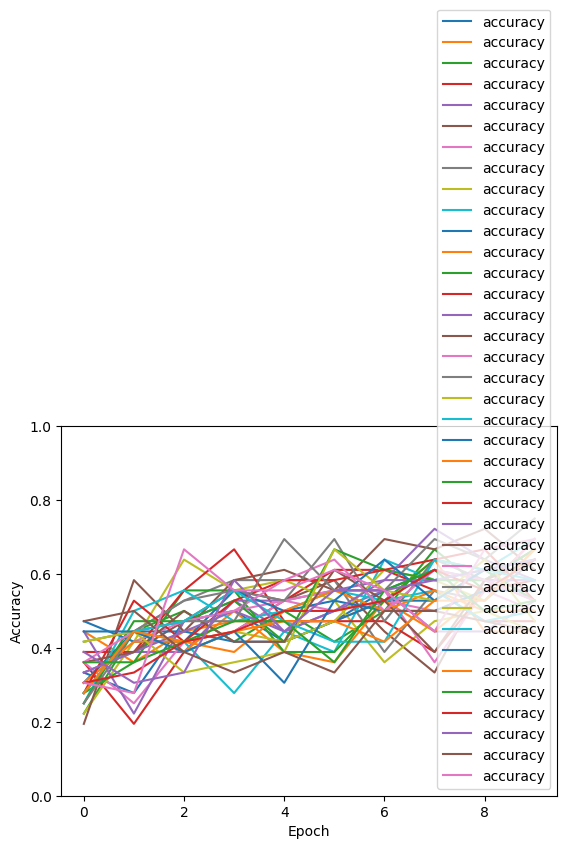

In [159]:
for i in range(len(results)):
    plt.plot(results[i]['sparse_categorical_accuracy'], label='accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')

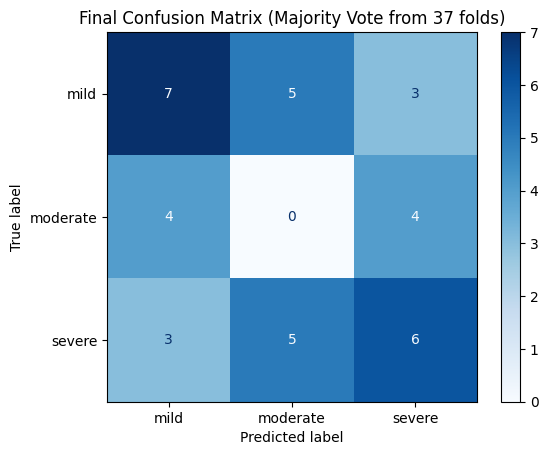

In [168]:
#print(pred_results)
pred_labels = []
true_labels = []
for i in range(len(pred_results)):
    pre = pred_results[i][1].tolist()
    pre = pre[0]
    pred_labels.append(pre.index(max(pre)))
    true_labels.append(label_dict[pred_results[i][0]])
    #print(pred_labels[i],true_labels[i])

fixed_labels = ["mild", "moderate", "severe"]
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Final Confusion Matrix (Majority Vote from 37 folds)")
plt.show()
